# 5.4 — The Training Loop: watch your math learn

Do the **pen-and-paper worksheet first**. Then run this top to bottom.

This is the notebook the whole curriculum has been building toward. Every function below is
yours: forward (5.1), loss (5.2), backward (5.3), step (Module 3.5). We wire them in a loop and
point them at data no straight line can split.

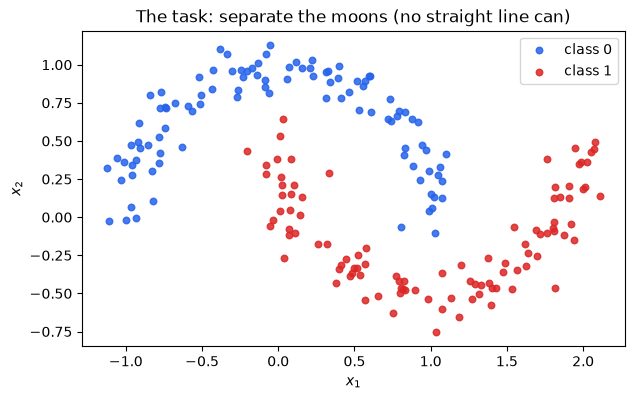

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # seeded randomness (Module 4.4) — same "random" every run

# Two interlocking crescent moons — built from circle points (cos, sin) + Gaussian noise (Module 4.3)
def make_moons(n_per_moon=100, noise=0.1):
    t = np.linspace(0, np.pi, n_per_moon)                       # angles around a half-circle
    top    = np.column_stack([np.cos(t), np.sin(t)])            # moon 0, arcing up
    bottom = np.column_stack([1 - np.cos(t), 0.5 - np.sin(t)])  # moon 1, arcing down, shifted
    X = np.vstack([top, bottom]) + rng.normal(0, noise, (2 * n_per_moon, 2))
    y = np.vstack([np.zeros((n_per_moon, 1)), np.ones((n_per_moon, 1))])  # labels: 0s then 1s
    return X, y

X, y = make_moons()
plt.figure(figsize=(7, 5.5))
plt.scatter(*X[y[:, 0] == 0].T, c="#2563eb", s=22, alpha=0.85, label="class 0")
plt.scatter(*X[y[:, 0] == 1].T, c="#dc2626", s=22, alpha=0.85, label="class 1")
plt.title("The task: separate the moons (no straight line can)")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.gca().set_aspect("equal")
plt.show()

## 1. The four moves, batch edition

Same math as notebooks 01–03, one upgrade: `X` holds ALL 200 points as rows (a data-table
matrix, Module 2.4), so one `@` runs *every* forward pass at once. And the loss/gradients are
**means over the batch** — Module 0.6's $\Sigma$ divided by $n$, Module 4.2's mean.

We give the network **8 hidden neurons** — the 2-2-1 was perfect for paper, but bendier
boundaries want a few more creases (each ReLU neuron contributes one crease — you saw yours
in notebook 01's plane picture).

In [2]:
n_hidden = 8
W1 = rng.normal(0, 1.0, (n_hidden, 2)); b1 = np.zeros(n_hidden)   # random start (Module 4.3)
W2 = rng.normal(0, 1.0, (1, n_hidden)); b2 = np.zeros(1)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1.T + b1                  # every point x every neuron, one matmul (Module 2.5)
    H  = np.maximum(0, Z1)              # ReLU (5.1)
    z2 = H @ W2.T + b2
    y_hat = 1 / (1 + np.exp(-z2))       # sigmoid (5.1)
    return Z1, H, y_hat

def mean_loss(y_hat, y):
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))   # 5.2, averaged (M0.6+M4.2)

def backward(X, y, Z1, H, y_hat, W2):
    d_z2 = (y_hat - y) / len(X)         # 5.3's prediction-minus-truth, averaged over the batch
    d_W2 = d_z2.T @ H                   # 5.3 Step 4 — .T is transpose: flip rows and columns
    d_b2 = d_z2.sum(axis=0)             # sum down the batch column
    d_H  = d_z2 @ W2                    # 5.3 Step 5: error flows back through the weights
    d_Z1 = d_H * (Z1 > 0)               # 5.3 Step 6: the ReLU gate
    d_W1 = d_Z1.T @ X                   # 5.3 Step 7
    d_b1 = d_Z1.sum(axis=0)
    return d_W1, d_b1, d_W2, d_b2

In [3]:
# THE LOOP: forward -> loss -> backward -> step, 3000 times.
# We photograph the network at chosen steps so we can watch the learning afterwards.
lr = 1.0
snapshots, losses = {}, []
snap_at = [0, 30, 100, 300, 1000, 3000]

for step in range(3001):
    Z1, H, y_hat = forward(X, W1, b1, W2, b2)             # forward   (5.1)
    losses.append(mean_loss(y_hat, y))                    # loss      (5.2)
    d_W1, d_b1, d_W2, d_b2 = backward(X, y, Z1, H, y_hat, W2)   # backward (5.3)
    if step in snap_at:                                   # (photograph before stepping)
        snapshots[step] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())
        acc = np.mean((y_hat > 0.5) == y)
        print(f"step {step:5d}   loss {losses[-1]:.4f}   accuracy {acc:.1%}")
    W1 -= lr * d_W1;  b1 -= lr * d_b1                     # step      (Module 3.5)
    W2 -= lr * d_W2;  b2 -= lr * d_b2

step     0   loss 0.6506   accuracy 57.5%
step    30   loss 0.2471   accuracy 89.5%
step   100   loss 0.2278   accuracy 89.0%
step   300   loss 0.0639   accuracy 98.5%
step  1000   loss 0.0078   accuracy 100.0%
step  3000   loss 0.0019   accuracy 100.0%


## 3. The loss curve — a shape you can now read

Every ML paper and every fast.ai lesson shows one of these. Yours starts where worksheet 5.2
predicted an ignorant classifier must start.

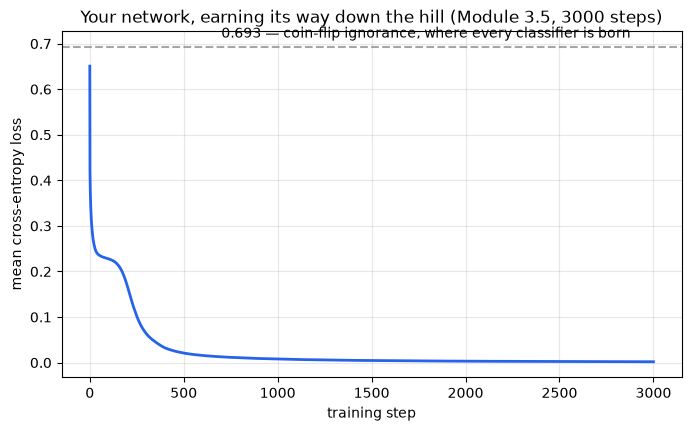

In [4]:
plt.figure(figsize=(8, 4.5))
plt.plot(losses, linewidth=2, color="#2563eb")
plt.axhline(np.log(2), color="grey", linestyle="--", alpha=0.7)
plt.annotate("0.693 — coin-flip ignorance, where every classifier is born",
             (700, np.log(2) + 0.02), fontsize=10)
plt.xlabel("training step"); plt.ylabel("mean cross-entropy loss")
plt.title("Your network, earning its way down the hill (Module 3.5, 3000 steps)")
plt.grid(alpha=0.3)
plt.show()

## 4. THE moment: the decision boundary, learning

Each panel colours the plane by the network's output — blue "class 0", red "class 1" — at one of
our snapshots. Watch the boundary start as a meaningless slash and *bend itself around the moons*.

Nobody drew that curve. Your Modules 0–4, in a loop, drew that curve.

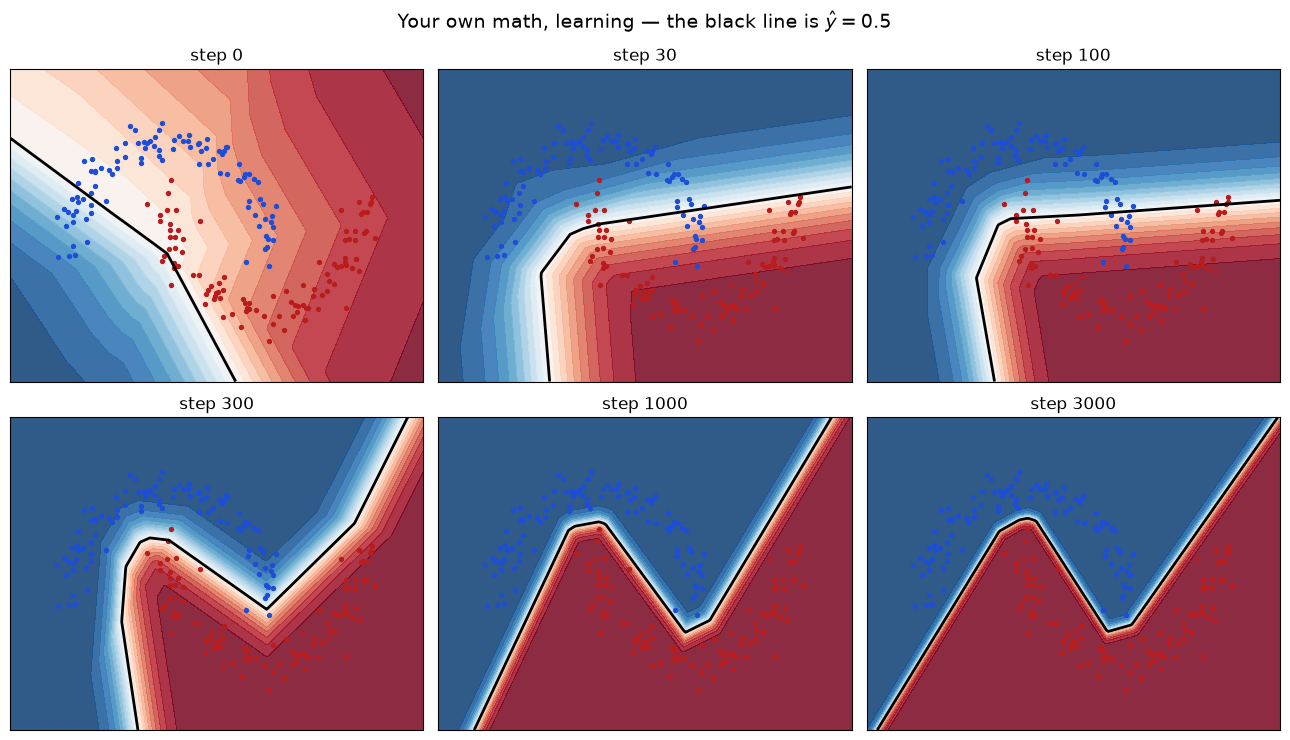

In [5]:
gx, gy = np.meshgrid(np.linspace(-1.6, 2.6, 220), np.linspace(-1.1, 1.6, 220))
grid = np.column_stack([gx.ravel(), gy.ravel()])     # .ravel() flattens the grid into a list of points

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, step in zip(axes.ravel(), snap_at):
    sW1, sb1, sW2, sb2 = snapshots[step]
    _, _, p = forward(grid, sW1, sb1, sW2, sb2)
    ax.contourf(gx, gy, p.reshape(gx.shape), levels=20, cmap="RdBu_r", vmin=0, vmax=1, alpha=0.85)
    ax.contour(gx, gy, p.reshape(gx.shape), levels=[0.5], colors="k", linewidths=2)  # the boundary
    ax.scatter(*X[y[:, 0] == 0].T, c="#1d4ed8", s=8)
    ax.scatter(*X[y[:, 0] == 1].T, c="#b91c1c", s=8)
    ax.set_title(f"step {step}", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Your own math, learning — the black line is $\\hat{y} = 0.5$", fontsize=14)
plt.tight_layout()
plt.show()

Sit with that for a second.

Matrix multiplication (Module 2), a squash (Module 1), a log-loss (Modules 0 and 4), the chain
rule (Module 3), and subtraction — and the machine *taught itself* to tell the moons apart.
That grid of pictures is, at honest scale, what happens inside GPT and stable diffusion during
training. You didn't import a neural network today. You **derived** one.

In [6]:
# YOUR TURN — experiment like an ML engineer. Re-run setup + training cells after each change.
# 1) Learning rate: try lr = 20.0 (watch the loss curve bounce or explode — worksheet C11 live),
#    then lr = 0.01 (watch it crawl). Reset to 1.0 after.
# 2) Capacity: n_hidden = 2 — our paper-sized network. Can it bend enough? n_hidden = 32?
# 3) Harder data: make_moons(noise=0.3). Where does the boundary struggle, and why?
# Record one sentence per experiment — noticing is the skill.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude what step-30 vs step-3000
felt like to watch. One unit left: 5.5 — convolutions, where this math meets images.*